# Fraud Detection in Mobile Money Transactions (PaySim)

In this project, I tackle the challenge of fraud detection in mobile-money ecosystems using PaySim - a large, high-fidelity synthetic dataset that mirrors real transaction flows and injected malicious behavior. The dataset (6.3M transactions, ~470 MB) can be downloaded from [Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1); it is not stored in this repository.

#### **Columns**

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

amount -
amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction.

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

isFlaggedFraud - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

NOTE: Transactions which are detected as fraud are cancelled, so for fraud detection these columns (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest ) must not be used.


#### **Importing dependencies**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro
from scipy.stats import spearmanr
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from lightgbm.sklearn import LGBMClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import joblib

#### **Data Extraction and Unpacking**

In [3]:
import zipfile

with zipfile.ZipFile('Synthetic Financial Datasets For Fraud Detection.zip', 'r') as zip:
    zip.extractall()

#### **Reading CSV**

In [4]:
df_financial = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df_financial.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


#### **Dataset Overview and Structure**

In [5]:
df_financial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


#### **Data Cleaning - Missing Values and Duplicates**

In [6]:
print("Missing Values:")
print(df_financial.isnull().sum())
print("Null 'amount' Values:")
print((df_financial['amount'] == 0).sum())
print('Number of Duplicates: ',df_financial.duplicated().sum())

Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
Null 'amount' Values:
16
Number of Duplicates:  0


#### **Exploratory Data Analysis (EDA)**

Let's take a look at the 16 transactions with null 'amount' values.

In [7]:
df_financial.loc[df_financial['amount'] == 0]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736447,212,CASH_OUT,0.0,C1510987794,0.0,0.0,C1696624817,0.00,0.00,1,0
3247298,250,CASH_OUT,0.0,C521393327,0.0,0.0,C480398193,0.00,0.00,1,0
3760289,279,CASH_OUT,0.0,C539112012,0.0,0.0,C1106468520,538547.63,538547.63,1,0
5563714,387,CASH_OUT,0.0,C1294472700,0.0,0.0,C1325541393,7970766.57,7970766.57,1,0
5996408,425,CASH_OUT,0.0,C832555372,0.0,0.0,C1462759334,76759.90,76759.90,1,0
5996410,425,CASH_OUT,0.0,C69493310,0.0,0.0,C719711728,2921531.34,2921531.34,1,0
6168500,554,CASH_OUT,0.0,C10965156,0.0,0.0,C1493336195,230289.66,230289.66,1,0
6205440,586,CASH_OUT,0.0,C1303719003,0.0,0.0,C900608348,1328472.86,1328472.86,1,0
6266414,617,CASH_OUT,0.0,C1971175979,0.0,0.0,C1352345416,0.00,0.00,1,0
6281483,646,CASH_OUT,0.0,C2060908932,0.0,0.0,C1587892888,0.00,0.00,1,0


**Insight**: Transactions with null 'amount' values are both fraudulent and withdrawals.

But is every fraudulent transaction a withdrawal with a null 'amount'?

In [8]:
df_financial.loc[df_financial['isFraud'] == 1]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


No.

**Insight**: Not every fraudulent transaction has a null 'amount'.

Let us examine the descriptive statistics of the dataset.

In [9]:
df_financial.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


It seems there are some outliers in the 'amount' statistics, possibly indicating fraudulent transactions. Let's examine the boxplot chart.

<Axes: ylabel='amount'>

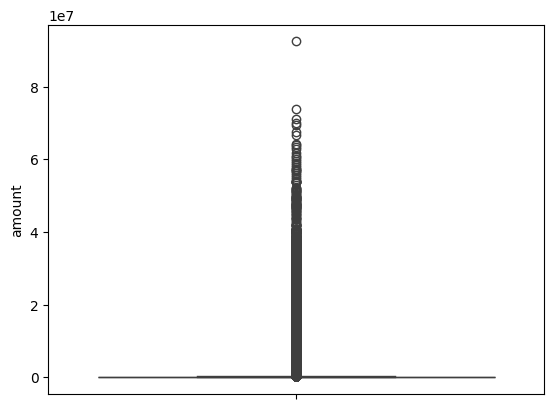

In [10]:
sns.boxplot(df_financial['amount'])

Since the linear scale is not appropriate, let's plot the 'amount' histogram for both legitimate and fraudulent transactions.

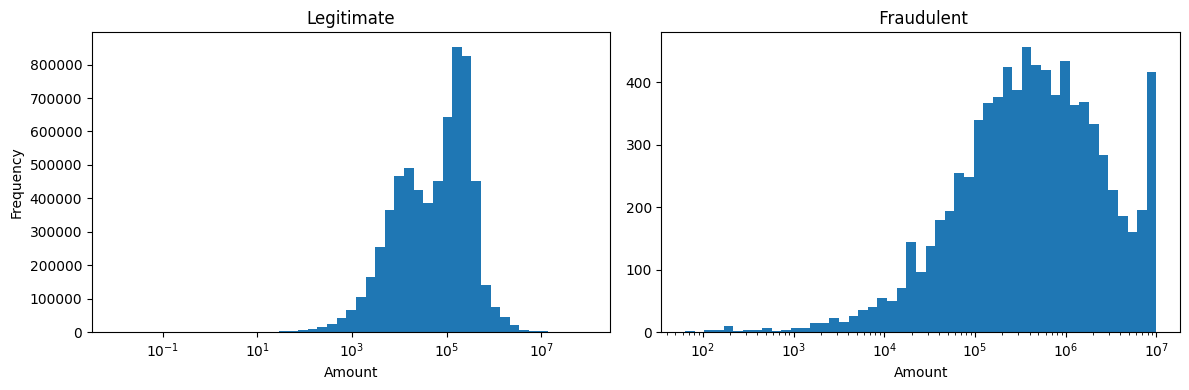

In [11]:
# separate values
fraud = df_financial.loc[df_financial['isFraud']==1, 'amount']
nonfraud = df_financial.loc[df_financial['isFraud']==0, 'amount']

# bins (log-scale, values > 0)
bins_nf = np.logspace(np.log10(nonfraud[nonfraud>0].min()),
                      np.log10(nonfraud.max()), 50)
bins_f  = np.logspace(np.log10(fraud[fraud>0].min()),
                      np.log10(fraud.max()), 50)

# plot side-by-side with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.hist(nonfraud, bins=bins_nf)
ax1.set_xscale('log')
ax1.set_title('Legitimate')
ax1.set_xlabel('Amount')
ax1.set_ylabel('Frequency')

ax2.hist(fraud, bins=bins_f)
ax2.set_xscale('log')
ax2.set_title(' Fraudulent')
ax2.set_xlabel('Amount')

plt.tight_layout()
plt.show()


**Insight**: Fraudulent transactions tend to have higher values more frequently compared to legitimate transactions.

Let's examine the statistical differences between the two.

In [12]:
df_financial.groupby("isFraud").describe()

step                                                           \
             count        mean         std  min    25%    50%    75%    max   
isFraud                                                                       
0        6354407.0  243.235663  142.140194  1.0  156.0  239.0  334.0  718.0   
1           8213.0  368.413856  216.388690  1.0  181.0  367.0  558.0  743.0   

            amount                ... newbalanceDest                \
             count          mean  ...            75%           max   
isFraud                           ...                                
0        6354407.0  1.781970e+05  ...    1111975.345  3.561793e+08   
1           8213.0  1.467967e+06  ...    1058725.220  2.367265e+08   

        isFlaggedFraud                                               
                 count      mean       std  min  25%  50%  75%  max  
isFraud                                                              
0            6354407.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  
1               8213.0  0.001948  0.044097  0.0  0.0  0.0  0.0  1.0  

[2 rows x 56 columns]

**Insight**: There are 6,354,407 legitimate and 8,213 fraudulent transactions.

Examining graphically transactions by type:

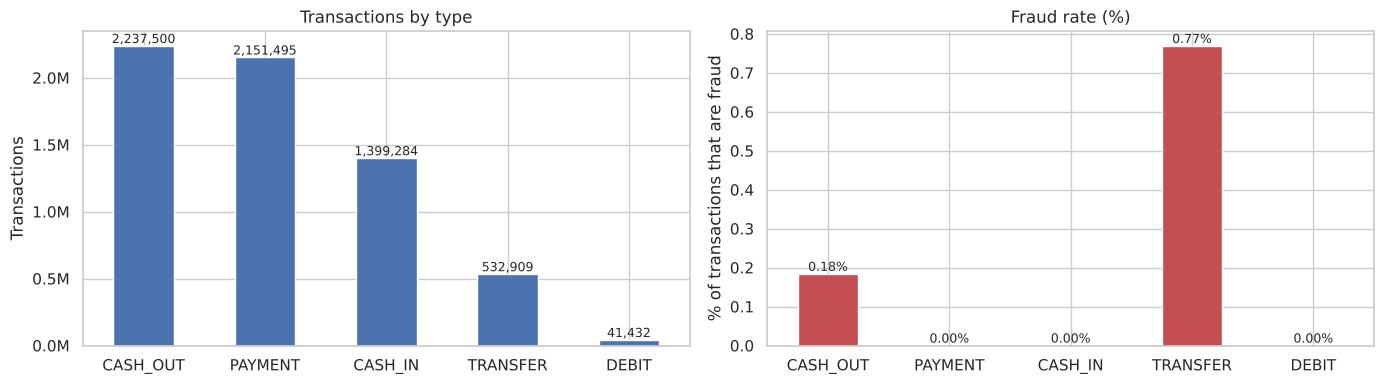

In [13]:
counts = (pd.crosstab(df_financial['type'], df_financial['isFraud'])
            .rename(columns={0: 'Legitimate', 1: 'Fraudulent'})
            .sort_values('Legitimate', ascending=False))
fraud_rate = counts['Fraudulent'] / counts.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts.sum(axis=1).plot.bar(ax=axes[0], color='C0')
axes[0].set(title='Transactions by type', xlabel='', ylabel='Transactions')
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v/1e6:.1f}M')
for i, v in enumerate(counts.sum(axis=1)):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

fraud_rate.plot.bar(ax=axes[1], color='C3')
axes[1].set(title='Fraud rate (%)', xlabel='', ylabel='% of transactions that are fraud')
for i, v in enumerate(fraud_rate):
    axes[1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Breaking down into legitimate and fraudulent transactions:

In [15]:
df_financial.loc[df_financial["isFraud"] == 0, 'type'].value_counts()

,count
type,
CASH_OUT,2233384
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,528812
DEBIT,41432


In [16]:
df_financial.loc[df_financial["isFraud"] == 1, 'type'].value_counts()

,count
type,
CASH_OUT,4116
TRANSFER,4097


**Insight**: Fraudulent transactions are either CASH_OUT or TRANSFER, in roughly equal numbers. But since transfers are much rarer overall, a TRANSFER is about 4 times more likely to be fraudulent (0.77% vs 0.18%). The crosstab below shows the split as percentages.

In [17]:
fraud_pct = pd.crosstab(
    df_financial['type'],
    df_financial['isFraud'],
    normalize='columns'
) * 100

fraud_pct.columns = ['Legitimate (%)', 'Fraudulent (%)']

print(fraud_pct)

          Legitimate (%)  Fraudulent (%)
type                                    
CASH_IN        22.020686         0.00000
CASH_OUT       35.147009        50.11567
DEBIT           0.652020         0.00000
PAYMENT        33.858313         0.00000
TRANSFER        8.321972        49.88433


Let's take a look at fraudulent and withdrawal transactions.

In [18]:
df_financial.loc[(df_financial['isFraud'] == 1) & (df_financial['type'] == 'CASH_OUT')]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
252,1,CASH_OUT,2806.00,C2101527076,2806.00,0.0,C1007251739,26202.00,0.00,1,0
681,1,CASH_OUT,20128.00,C1118430673,20128.00,0.0,C339924917,6268.00,12145.85,1,0
724,1,CASH_OUT,416001.33,C749981943,0.00,0.0,C667346055,102.00,9291619.62,1,0
970,1,CASH_OUT,1277212.77,C467632528,1277212.77,0.0,C716083600,0.00,2444985.19,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362611,742,CASH_OUT,63416.99,C994950684,63416.99,0.0,C1662241365,276433.18,339850.17,1,0
6362613,743,CASH_OUT,1258818.82,C1436118706,1258818.82,0.0,C1240760502,503464.50,1762283.33,1,0
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0


In CASH_OUT transactions, the recipient is an external entity (typically an ATM or merchant) whose name always starts with the letter 'M'. Here, we see that some CASH_OUT transactions start with the letter 'C', which technically is not a cash withdrawal. It would be a TRANSFER between customers. Let's check if there are any CASH_OUT transactions, whether fraudulent or legitimate, where the recipient starts with 'M'.


In [19]:
df_financial.loc[df_financial.type == 'CASH_OUT'].nameDest.str.contains('M').any()

np.False_

**Insight**: There is no 'merchant' or ATM as the destination for CASH_OUT transactions, which is incongruent.

#### **Feature Engineering**

Let's classify the transactions by type: Customer to Customer (C2C), Customer to Merchant (C2M), Merchant to Customer (M2C), and Merchant to Merchant (M2M).

In [20]:
df_financial['trans_direction'] = 'Unknown'

In [21]:
df_financial.loc[df_financial.nameOrig.str.startswith('C') & df_financial.nameDest.str.startswith('C'), 'trans_direction'] = 'C2C'
df_financial.loc[df_financial.nameOrig.str.startswith('C') & df_financial.nameDest.str.startswith('M'), 'trans_direction'] = 'C2M'
df_financial.loc[df_financial.nameOrig.str.startswith('M') & df_financial.nameDest.str.startswith('C'), 'trans_direction'] = 'M2C'
df_financial.loc[df_financial.nameOrig.str.startswith('M') & df_financial.nameDest.str.startswith('M'), 'trans_direction'] = 'M2M'
df_financial.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,trans_direction
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,C2M
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,C2M
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C2C
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C2C
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,C2M


Removing the origin and destination identifier columns to avoid potential overfitting in the ML model.

In [22]:
df_financial.drop(columns = ['nameOrig','nameDest'], axis = 'columns', inplace = True)

Adjusting the position of the 'trans_direction' column to improve table readability.

In [23]:
col = df_financial.pop('trans_direction')

df_financial.insert(loc=1, column='trans_direction', value=col)
df_financial.head(5)

,step,trans_direction,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,C2M,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,C2M,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,C2C,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,C2C,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,C2M,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


Let's look at the number of transactions by type.

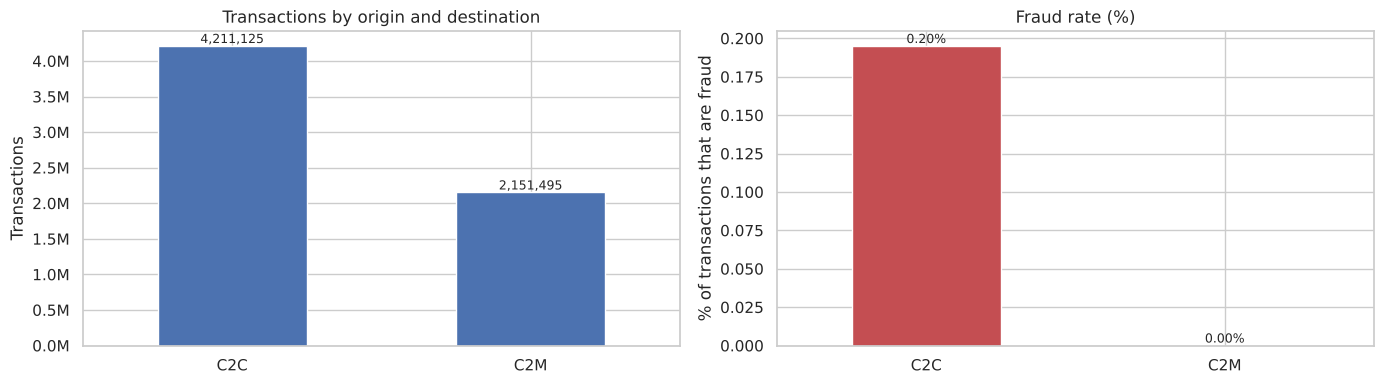

In [24]:
counts = (pd.crosstab(df_financial['trans_direction'], df_financial['isFraud'])
            .rename(columns={0: 'Legitimate', 1: 'Fraudulent'})
            .sort_values('Legitimate', ascending=False))
fraud_rate = counts['Fraudulent'] / counts.sum(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts.sum(axis=1).plot.bar(ax=axes[0], color='C0')
axes[0].set(title='Transactions by origin and destination', xlabel='', ylabel='Transactions')
axes[0].yaxis.set_major_formatter(lambda v, _: f'{v/1e6:.1f}M')
for i, v in enumerate(counts.sum(axis=1)):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

fraud_rate.plot.bar(ax=axes[1], color='C3')
axes[1].set(title='Fraud rate (%)', xlabel='', ylabel='% of transactions that are fraud')
for i, v in enumerate(fraud_rate):
    axes[1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Evaluating the amount of fraudulent and legitimate transactions by origin-destination type.

In [25]:
print('Number of fraud transactions according to trans_direction:\n', df_financial.loc[df_financial['isFraud'] == 1, 'trans_direction'].value_counts(), '\n')
print('Number of legitimate transactions according to trans_direction:\n', df_financial.loc[df_financial['isFraud'] == 0, 'trans_direction'].value_counts())

Number of fraud transactions according to trans_direction:
 trans_direction
C2C    8213
Name: count, dtype: int64 

Number of legitimate transactions according to trans_direction:
 trans_direction
C2C    4202912
C2M    2151495
Name: count, dtype: int64


**Insight**: Every fraudulent transaction is a CASH_OUT or TRANSFER between two customer (C2C) accounts. Payments to merchants (C2M) are never fraudulent in this dataset.

When a transaction is identified as fraud in the simulated system, it is not actually completed and is immediately canceled. Therefore, the balances before and after the transaction (the columns oldbalanceOrg, newbalanceOrig, oldbalanceDest and newbalanceDest) do not reflect any real movement for these cases. Therefore, to avoid data leakage, we will exclude these columns.

In [26]:
df_financial.drop(columns = ['oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest'], axis = 'columns', inplace = True)
df_financial.head(5)

,step,trans_direction,type,amount,isFraud,isFlaggedFraud
0,1,C2M,PAYMENT,9839.64,0,0
1,1,C2M,PAYMENT,1864.28,0,0
2,1,C2C,TRANSFER,181.00,1,0
3,1,C2C,CASH_OUT,181.00,1,0
4,1,C2M,PAYMENT,11668.14,0,0


Since categorical data does not have an inherent ordinal relationship, we will use one-hot encoding.

In [27]:
df_financial = pd.get_dummies(df_financial, prefix = ['trans_direction', 'type'], drop_first = True)
df_financial.head(5)

,step,amount,isFraud,isFlaggedFraud,trans_direction_C2M,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,0,0,True,False,False,True,False
1,1,1864.28,0,0,True,False,False,True,False
2,1,181.00,1,0,False,False,False,False,True
3,1,181.00,1,0,False,True,False,False,False
4,1,11668.14,0,0,True,False,False,True,False


Splitting the dataset into training and testing parts.

In [28]:
x = df_financial.drop('isFraud', axis=1)
y = df_financial.isFraud

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.30, stratify = df_financial.isFraud)
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

#### **Model building**

Four classifiers are trained on the same split: a linear baseline (Logistic Regression) and three tree ensembles (Random Forest, LightGBM and XGBoost).

In [29]:
rfc = RandomForestClassifier(
    n_estimators=15,    # number of trees in the forest
    n_jobs=-1,          # uses all available CPU cores
    random_state=42     # seed for reproducibility
)
lgbm = LGBMClassifier(
    boosting_type='gbdt',  # Gradient Boosting Decision Tree (LightGBM default)
    objective='binary',    # binary classification problem
    random_state=8888      # different seed, to vary the pseudo-random
)
xgbr = xgb.XGBClassifier(
    max_depth=3,         # maximum depth of each tree
    n_jobs=-1,           # uses all cores for training
    random_state=42,     # reproducibility
    learning_rate=0.1    # boosting learning rate (shrinkage)
)
logreg = LogisticRegression(
    solver='liblinear',  # optimization algorithm (good for smaller datasets)
    random_state=42      # seed for regularization/algorithm
)

rfc.fit(x_train, y_train)
lgbm.fit(x_train, y_train)
xgbr.fit(x_train, y_train)
logreg.fit(x_train, y_train)

classifiers = []
classifiers.append(rfc)
classifiers.append(lgbm)
classifiers.append(xgbr)
classifiers.append(logreg)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4448085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.221884 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 527
[LightGBM] [Info] Number of data points in the train set: 4453834, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651203
[LightGBM] [Info] Start training from score -6.651203


#### **Model Evaluation**


=== RandomForestClassifier ===
              precision    recall  f1-score   support

           0     0.9992    0.9998    0.9995   1906322
           1     0.7203    0.3470    0.4684      2464

    accuracy                         0.9990   1908786
   macro avg     0.8597    0.6734    0.7339   1908786
weighted avg     0.9988    0.9990    0.9988   1908786

ROC AUC: 0.7936



=== LGBMClassifier ===
              precision    recall  f1-score   support

           0     0.9990    0.9998    0.9994   1906322
           1     0.5860    0.1976    0.2956      2464

    accuracy                         0.9988   1908786
   macro avg     0.7925    0.5987    0.6475   1908786
weighted avg     0.9984    0.9988    0.9985   1908786

ROC AUC: 0.8855

=== XGBClassifier ===
              precision    recall  f1-score   support

           0     0.9989    1.0000    0.9995   1906322
           1     0.9227    0.1745    0.2935      2464

    accuracy                         0.9989   1908786
   macro avg     0.9608    0.5872    0.6465   1908786
weighted avg     0.9988    0.9989    0.9985   1908786

ROC AUC: 0.9556

=== LogisticRegression ===
              precision    recall  f1-score   support

           0     0.9987    1.0000    0.9993   1906322
           1     0.1818    0.0024    0.0048      2464

    accuracy                         0.9987   1908786
   macro avg     0.59

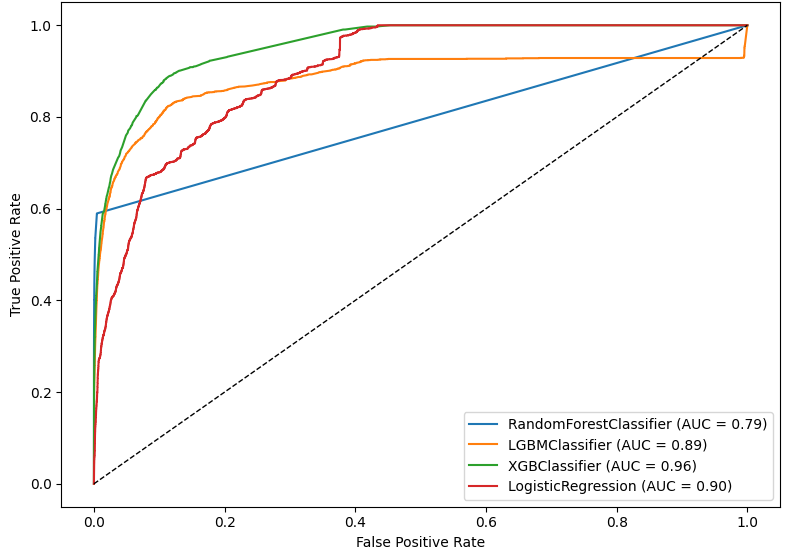


Best model: XGBClassifier with AUC = 0.9556


['best_fraud_model.pkl']

In [30]:
results = []
for clf in classifiers:
    name = clf.__class__.__name__
    # class and probability prediction
    y_pred = clf.predict(x_test)
    y_proba = clf.predict_proba(x_test)[:,1]

    # metrics
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=4))
    auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC: {auc:.4f}")

    results.append((name, auc))

# 2) ROC curves side by side
plt.figure(figsize=(8,6))
for clf in classifiers:
    y_proba = clf.predict_proba(x_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{clf.__class__.__name__} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3) Identify and save the best model
best_name, best_auc = max(results, key=lambda x: x[1])
best_model = next(m for m in classifiers if m.__class__.__name__ == best_name)
print(f"\nBest model: {best_name} with AUC = {best_auc:.4f}")
joblib.dump(best_model, "best_fraud_model.pkl")

#### **Conclusions**


#### **Conclusions**

- Fraud is rare: 8,213 of 6,362,620 transactions (0.13%).
- Every fraud is a CASH_OUT or TRANSFER between two customer accounts (C2C). Transfers carry the highest fraud rate (0.77%), and fraudulent amounts are skewed towards higher values than legitimate ones.
- XGBoost has the best ranking ability (ROC AUC = 0.956), ahead of Logistic Regression (0.901), LightGBM (0.886) and Random Forest (0.794).


#### **Interpreting the results**

With only 0.13% fraud, ROC AUC alone can be misleading. A model can rank transactions well and still miss most frauds at the default 0.5 threshold. At that threshold:

| Model | Precision (fraud) | Recall (fraud) | F1 (fraud) | ROC AUC |
|---|---|---|---|---|
| XGBoost | 0.92 | 0.17 | 0.29 | 0.956 |
| Random Forest | 0.72 | 0.35 | 0.47 | 0.794 |
| LightGBM | 0.59 | 0.20 | 0.30 | 0.886 |
| Logistic Regression | 0.18 | 0.00 | 0.00 | 0.901 |

XGBoost is very precise (92% of flagged transactions are fraud) but catches only 17% of frauds. Missing a fraud usually costs much more than reviewing a false alarm, so the threshold should be chosen from these costs instead of left at 0.5.

Removing the balance columns (to avoid leakage, as the dataset documentation requires) leaves the models with only `step`, `amount`, `type` and `trans_direction`, so a modest recall is expected.

#### **Next steps**

1. **Precision-recall evaluation:** report PR-AUC (average precision) and plot the precision-recall curve, which is more informative than ROC for rare events.
2. **Threshold tuning** on a validation set to hit a target recall (e.g. 80%) and report the resulting precision / alert volume.
3. **Class imbalance:** try `scale_pos_weight` (XGBoost) or `class_weight='balanced'`, and compare against the current models.
4. **Time-based validation:** train on the first weeks (`step`) and test on the last, to mimic deployment.
5. **More features from the allowed columns:** hour of day (`step % 24`), amount relative to the customer's history, transaction velocity per account.